# Pipeline Design and Premises 

## Time Distortion Index (TDI)

**Time distortion index (TDI) is a metric used to quantify differences between time series, and its formulation varies across applications (Frías-Paredes et al., 2016; Liu et al., 2023).**

`tdi_plot.py` tracks how growth rate and biomass change across adjacent generations for each knockout variant. It summarizes whether the time-series trajectories are converging over time.

The metrics are:

- `dtw_distance`: the shape-difference term. It applies Dynamic Time Warping (DTW) to the two time series, so it captures overall trajectory shape changes even when the curves are slightly shifted in time (Alqahtani et al., 2021). It  is normalized by the minimum length and mean value of two aligned time series so become unitless and indicates how much deviation exists between each pair of time points.
- `duration_ratio`: the time-span term. It is computed as `abs(dur2 / dur1 - 1)`, where `dur1` and `dur2` are the total time ranges of the two generations. A value of `0` means the durations are unchanged.
- `amplitude_ratio`: the scale term. It is computed as `abs(s2.max() / s1.max() - 1)`, so it compares the peak value of the later generation with the previous one. A value of `0` means the peak size is unchanged.
- `composite_tdi`: the final summary score. It is the average of the three terms above: `(dtw_distance + duration_ratio + amplitude_ratio) / 3`. Lower values mean the adjacent generations are more similar overall.

How it is used here: for each knockout, the script loads the saved time-series, compares generation pairs such as `1-2`, `2-3`, `3-4`, and so on, and computes these metrics for growth rate and biomass. The aggregated plots then place all knockouts into one graph so the generation-level convergence trend can be seen across the full project.

# Code


## Summary
(Only the basal simulation data is loaded as example, and saved as df)

In [12]:
# Load the saved summary and read the biomass/growth rate
import pandas as pd
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_gene_ko_40trial_basal_all.csv"
df = pd.read_csv(path)

print('source path:', path)
print('shape:', df.shape)
print('columns:', list(df.columns))
print('dtypes:')
print(df.dtypes.to_string())

key_cols = [col for col in ['variant', 'generation', 'lineage_seed'] if col in df.columns]
for col in key_cols:
    print(f'{col} unique:', df[col].nunique(), 'values:', sorted(df[col].dropna().unique())[:10])

if 'time' in df.columns:
    print('time range:', df['time'].min(), 'to', df['time'].max())

print('missing values:')
print(df.isna().sum().to_string())
print('head:')
print(df.head(3).to_string())

source path: /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_gene_ko_40trial_basal_all.csv
shape: (80, 15)
columns: ['project', 'variant', 'label', 'lineage_seed', 'mean_growth_rate', 'median_growth_rate', 'std_growth_rate', 'max_growth_rate', 'initial_dry_mass', 'final_dry_mass', 'max_dry_mass', 'fold_change_mass', 'duration_sec', 'n_timepoints', 'max_generation']
dtypes:
project                object
variant                 int64
label                  object
lineage_seed            int64
mean_growth_rate      float64
median_growth_rate    float64
std_growth_rate       float64
max_growth_rate       float64
initial_dry_mass      float64
final_dry_mass        float64
max_dry_mass          float64
fold_change_mass      float64
duration_sec          float64
n_timepoints            int64
max_generation          int64
variant unique: 40 values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)

In [13]:
print(df.head(20).to_string())

                          project  variant        label  lineage_seed  mean_growth_rate  median_growth_rate  std_growth_rate  max_growth_rate  initial_dry_mass  final_dry_mass  max_dry_mass  fold_change_mass  duration_sec  n_timepoints  max_generation
0   gene_ko_40trial_seed100_basal        1  KO: EG10003           100          0.000220            0.000225         0.000038         0.000303        266.608085      639.778933    762.705903          2.399698       50156.0           845              16
1   gene_ko_40trial_seed100_basal        1  KO: EG10003           101          0.000210            0.000212         0.000059         0.000768        410.036277      579.523132    762.181781          1.413346       50314.0           846              16
2   gene_ko_40trial_seed100_basal        2  KO: EG10013           100          0.000214            0.000217         0.000042         0.000406        266.615436      691.848220    767.358479          2.594929       51968.0           875         

## Time-series

### 40 trial KO - basal media

#### Individual plot

In [17]:
# Load the saved time-series and read the biomass/growth rate
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_ko_40trial_basal_all.parquet"
import pandas as pd
df_t = pd.read_parquet(path)
print('shape', df_t.shape)
print('columns', list(df_t.columns))
print('dtypes')
print(df_t.dtypes.to_string())
print('head')
print(df_t.head(5).to_string())

shape (62492, 8)
columns ['project', 'variant', 'label', 'lineage_seed', 'generation', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
dtypes
project                                        object
variant                                         int64
label                                          object
lineage_seed                                    int64
generation                                      int64
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
head
                         project  variant        label  lineage_seed  generation   time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
0  gene_ko_40trial_seed100_basal        1  KO: EG10003           100           1    0.0                                    0.000000                 266.608085
1  gene_ko_40trial_seed100_basal        1  KO: EG10003           100

In [ ]:
print(df_t.tail(5).to_string())

                             project  variant        label  lineage_seed  generation     time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
62487  gene_ko_40trial_seed100_basal       40  KO: EG10054           101          16  49450.0                                    0.000203                 639.603853
62488  gene_ko_40trial_seed100_basal       40  KO: EG10054           101          16  49510.0                                    0.000216                 669.864017
62489  gene_ko_40trial_seed100_basal       40  KO: EG10054           101          16  49570.0                                    0.000209                 678.433490
62490  gene_ko_40trial_seed100_basal       40  KO: EG10054           101          16  49630.0                                    0.000214                 687.157424
62491  gene_ko_40trial_seed100_basal       40  KO: EG10054           101          16  49690.0                                    0.000212                 696.017514


Sample command:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_basal
    --project-folder gene_ko_40trial_seed100_basal \
    --variants 1 \
    --generations 1:16
```

In [5]:
"""Customise command for each variant and generation range"""

variant_col = 'variant'
generation_col = 'generation'

if variant_col not in df_t.columns or generation_col not in df_t.columns:
    raise ValueError('The loaded CSV must contain variant and generation columns.')

for variant, variant_df in df_t.groupby(variant_col):
    max_generation = int(variant_df[generation_col].max())
    if variant_df[generation_col].nunique() <= 1:
        continue

    command = f"""python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --project-folder gene_ko_40trial_seed100_basal \
    --variants {variant} \
    --generations 1:{max_generation}"""

    print(command)

python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 1     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 2     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 3     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 4     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 6     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basal     --variants 7     --generations 1:3
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --project-folder gene_ko_40trial_seed100_basa

#### Aggregated plot

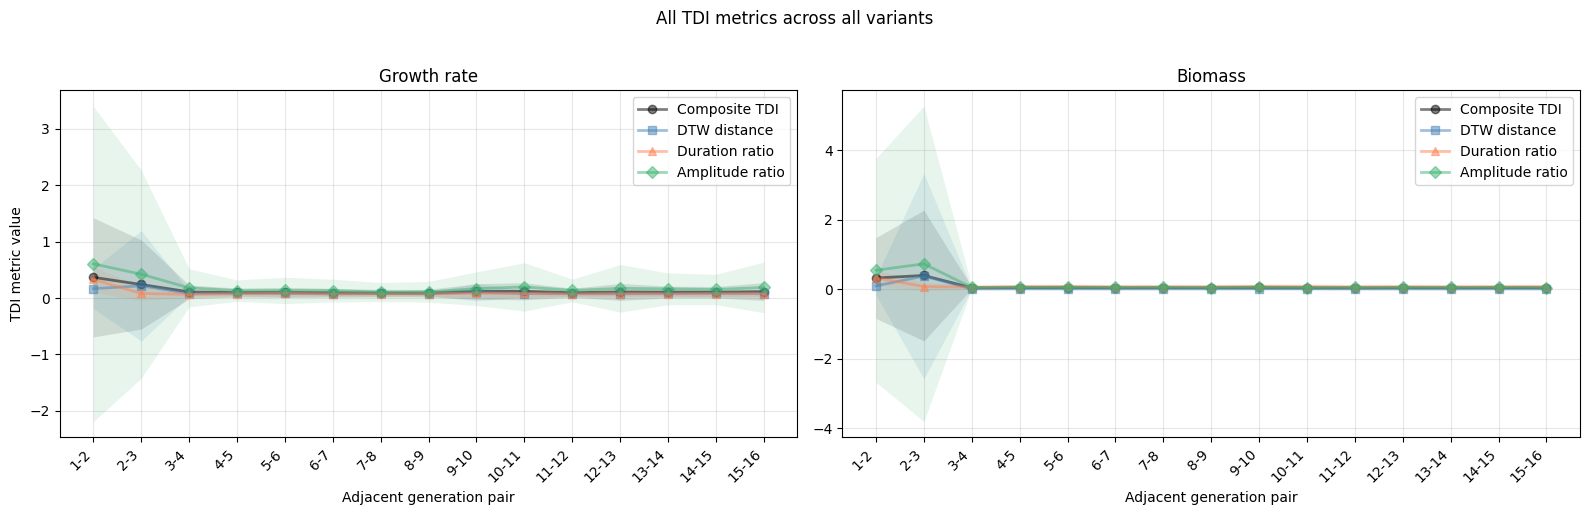

        feature generation_pair  composite_tdi_mean  composite_tdi_std  \
0       Biomass             1-2            0.325784           1.164397   
7       Biomass             2-3            0.398880           1.880771   
8       Biomass             3-4            0.043795           0.023729   
9       Biomass             4-5            0.050702           0.025043   
10      Biomass             5-6            0.052098           0.033497   
11      Biomass             6-7            0.047340           0.025631   
12      Biomass             7-8            0.048894           0.026860   
13      Biomass             8-9            0.047066           0.023845   
14      Biomass            9-10            0.053327           0.042605   
1       Biomass           10-11            0.048570           0.037279   
2       Biomass           11-12            0.045860           0.029796   
3       Biomass           12-13            0.047742           0.027397   
4       Biomass           13-14       

In [18]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the compute_tdi function from tdi_plot.py (use reload to use the latest version)
import importlib
import tdi_plot
importlib.reload(tdi_plot)
compute_tdi = tdi_plot.compute_tdi

# Set project name and seed list
project = "gene_ko_40trial_seed100_basal"
seed_list = [100, 101]

# Check if df_t is available
if 'df_t' not in globals():
    raise ValueError('df_t is not available. Load the time-series parquet into df_t first.')

# Validate and copy the required columns are present in df_t
ts = df_t.copy()
required_cols = {'variant', 'generation', 'time'}
missing = required_cols.difference(ts.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
feature_map = {
    'Growth rate': 'listeners__mass__instantaneous_growth_rate',
    'Biomass': 'listeners__mass__dry_mass',
}
feature_map = {label: col for label, col in feature_map.items() if col in ts.columns}
if not feature_map:
    raise ValueError('No supported TDI feature columns were found in df_t.')

# Compute TDI metrics for each variant and adjacent generation pairs
records = []
generation_pairs = sorted(ts['generation'].dropna().unique())
for seed in seed_list:
    for variant, variant_df in ts.groupby('variant'):
        variant_df = variant_df.sort_values(['generation', 'time', 'lineage_seed'])
        variant_df = variant_df[variant_df['lineage_seed'] == seed]
        for gen_prev, gen_curr in zip(generation_pairs[:-1], generation_pairs[1:]):
            prev_df = variant_df[variant_df['generation'] == gen_prev]
            curr_df = variant_df[variant_df['generation'] == gen_curr]
            if prev_df.empty or curr_df.empty:
                continue
            for feature_label, feature_col in feature_map.items():
                metrics = compute_tdi(prev_df, curr_df, feature_col)
                records.append(
                    {
                        'variant': variant,
                        'feature': feature_label,
                        'generation_pair': f'{gen_prev}-{gen_curr}',
                        'seed': seed,
                        **metrics,
                    }
                )

results = pd.DataFrame(records)
if results.empty:
    raise ValueError('No TDI records were computed. Check that df_t contains multiple generations for each variant.')

metric_order = ['composite_tdi', 'dtw_distance', 'duration_ratio', 'amplitude_ratio']
metric_labels = {
    'composite_tdi': 'Composite TDI',
    'dtw_distance': 'DTW distance',
    'duration_ratio': 'Duration ratio',
    'amplitude_ratio': 'Amplitude ratio',
}
metric_colors = {
    'composite_tdi': 'black',
    'dtw_distance': 'steelblue',
    'duration_ratio': 'coral',
    'amplitude_ratio': 'mediumseagreen',
}
metric_markers = {
    'composite_tdi': 'o',
    'dtw_distance': 's',
    'duration_ratio': '^',
    'amplitude_ratio': 'D',
}
metric_fill_alpha = 0.12

summary = (
    results.groupby(['feature', 'generation_pair'], as_index=False)
    .agg(
        composite_tdi_mean=('composite_tdi', 'mean'),
        composite_tdi_std=('composite_tdi', 'std'),
        dtw_distance_mean=('dtw_distance', 'mean'),
        dtw_distance_std=('dtw_distance', 'std'),
        duration_ratio_mean=('duration_ratio', 'mean'),
        duration_ratio_std=('duration_ratio', 'std'),
        amplitude_ratio_mean=('amplitude_ratio', 'mean'),
        amplitude_ratio_std=('amplitude_ratio', 'std'),
        count=('composite_tdi', 'count'),
    )
)
summary = summary.fillna(0.0)
summary['generation_start'] = summary['generation_pair'].str.split('-').str[0].astype(int)
summary = summary.sort_values(['feature', 'generation_start'])

save_dir = "/user/home/il22158/work/vEcoli/reading/results/tdi"
os.makedirs(save_dir, exist_ok=True)

combined_name = "tdi_all_variants_growth_rate_biomass_4metrics_mean_std.png"

fig, axes = plt.subplots(1, len(feature_map), figsize=(16, 5), sharey=False)
if len(feature_map) == 1:
    axes = [axes]

for ax, (feature_label, _) in zip(axes, feature_map.items()):
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()

    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(feature_label)
    ax.set_xlabel('Adjacent generation pair')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('TDI metric value')
fig.suptitle('All TDI metrics across all variants', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, combined_name), dpi=300, bbox_inches='tight')
plt.show()

for feature_label in feature_map:
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()
    feature_slug = feature_label.lower().replace(' ', '_')

    fig_feature, ax_feature = plt.subplots(figsize=(9, 4.8))
    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax_feature.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax_feature.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax_feature.set_xticks(x)
    ax_feature.set_xticklabels(labels, rotation=45, ha='right')
    ax_feature.set_title(f'{project} - All TDI metrics across all variants')
    ax_feature.set_xlabel('Adjacent generation pair')
    ax_feature.set_ylabel('TDI metric value')
    ax_feature.grid(True, alpha=0.3)
    ax_feature.legend(loc='best')
    fig_feature.tight_layout()
    fig_feature.savefig(
        os.path.join(save_dir, f'tdi_all_variants_{project}_{feature_slug}_4metrics_mean_std.png'),
        bbox_inches='tight',
    )
    plt.close(fig_feature)

print(summary)
summary.to_csv(os.path.join(save_dir, f'tdi_all_variants_{project}_4metrics_mean_std.csv'), index=False)

### 40 trial KO - aa

#### Individual plot

In [14]:
# Load the saved time-series and read the biomass/growth rate
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_ko_40trial_aa_all.parquet"
import pandas as pd
df_t = pd.read_parquet(path)
print('shape', df_t.shape)
print('columns', list(df_t.columns))
print('dtypes')
print(df_t.dtypes.to_string())
print('head')
print(df_t.head(5).to_string())

shape (35923, 8)
columns ['project', 'variant', 'label', 'lineage_seed', 'generation', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
dtypes
project                                        object
variant                                         int64
label                                          object
lineage_seed                                    int64
generation                                      int64
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
head
                      project  variant        label  lineage_seed  generation   time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
0  gene_ko_40trial_seed100_aa        1  KO: EG10003           100           1    0.0                                    0.000000                 564.130406
1  gene_ko_40trial_seed100_aa        1  KO: EG10003           100         

In [26]:
print(df_t.tail(5).to_string())

                          project  variant        label  lineage_seed  generation    time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
35918  gene_ko_40trial_seed100_aa       40  KO: EG10054           101           1  2400.0                                    0.000095                1133.495926
35919  gene_ko_40trial_seed100_aa       40  KO: EG10054           101           1  2460.0                                    0.000097                1140.050570
35920  gene_ko_40trial_seed100_aa       40  KO: EG10054           101           1  2520.0                                    0.000095                1146.624224
35921  gene_ko_40trial_seed100_aa       40  KO: EG10054           101           1  2580.0                                    0.000093                1153.257177
35922  gene_ko_40trial_seed100_aa       40  KO: EG10054           101           1  2640.0                                    0.000097                1159.837657


Sample command:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa \
    --project-folder gene_ko_40trial_seed100_aa \
    --variants 1 \
    --generations 1:16
```

In [7]:
"""Customise command for each variant and generation range"""

variant_col = 'variant'
generation_col = 'generation'

if variant_col not in df_t.columns or generation_col not in df_t.columns:
    raise ValueError('The loaded CSV must contain variant and generation columns.')

for variant, variant_df in df_t.groupby(variant_col):
    max_generation = int(variant_df[generation_col].max())
    if variant_df[generation_col].nunique() <= 1:
        continue

    command = f"""python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa \
    --project-folder gene_ko_40trial_seed100_aa \
    --variants {variant} \
    --generations 1:{max_generation}"""

    print(command)

python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa     --project-folder gene_ko_40trial_seed100_aa     --variants 1     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa     --project-folder gene_ko_40trial_seed100_aa     --variants 2     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa     --project-folder gene_ko_40trial_seed100_aa     --variants 3     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_aa     --project-folder gene_ko_40trial_seed100_aa     --variants 4     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEc

#### Aggregated plot

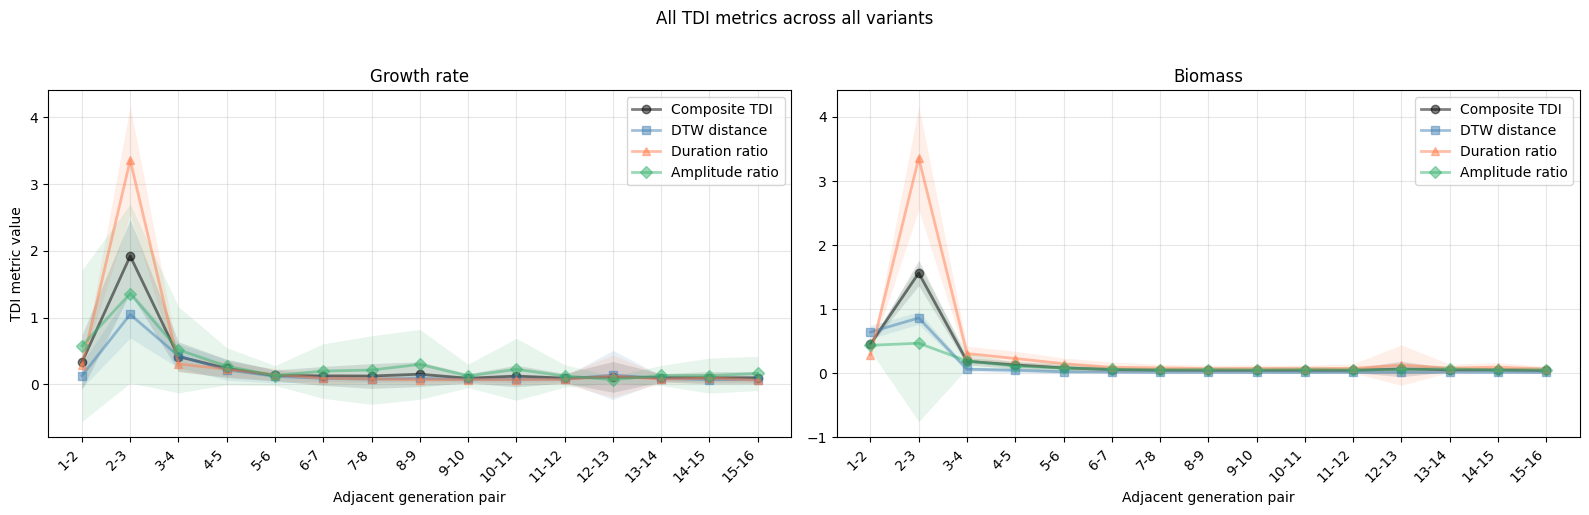

        feature generation_pair  composite_tdi_mean  composite_tdi_std  \
0       Biomass             1-2            0.454221           0.012375   
7       Biomass             2-3            1.563177           0.199153   
8       Biomass             3-4            0.186208           0.055168   
9       Biomass             4-5            0.128060           0.058888   
10      Biomass             5-6            0.083341           0.046450   
11      Biomass             6-7            0.056724           0.032958   
12      Biomass             7-8            0.048395           0.026313   
13      Biomass             8-9            0.046327           0.024337   
14      Biomass            9-10            0.045529           0.023072   
1       Biomass           10-11            0.046606           0.033886   
2       Biomass           11-12            0.045792           0.033543   
3       Biomass           12-13            0.065604           0.122312   
4       Biomass           13-14       

In [16]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the compute_tdi function from tdi_plot.py (use reload to use the latest version)
import importlib
import tdi_plot
importlib.reload(tdi_plot)
compute_tdi = tdi_plot.compute_tdi

# Set project name and seed list
project = "gene_ko_40trial_seed100_aa"
seed_list = [100, 101]

# Check if df_t is available
if 'df_t' not in globals():
    raise ValueError('df_t is not available. Load the time-series parquet into df_t first.')

# Validate and copy the required columns are present in df_t
ts = df_t.copy()
required_cols = {'variant', 'generation', 'time'}
missing = required_cols.difference(ts.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
feature_map = {
    'Growth rate': 'listeners__mass__instantaneous_growth_rate',
    'Biomass': 'listeners__mass__dry_mass',
}
feature_map = {label: col for label, col in feature_map.items() if col in ts.columns}
if not feature_map:
    raise ValueError('No supported TDI feature columns were found in df_t.')

# Compute TDI metrics for each variant and adjacent generation pairs
records = []
generation_pairs = sorted(ts['generation'].dropna().unique())
for seed in seed_list:
    for variant, variant_df in ts.groupby('variant'):
        variant_df = variant_df.sort_values(['generation', 'time', 'lineage_seed'])
        variant_df = variant_df[variant_df['lineage_seed'] == seed]
        for gen_prev, gen_curr in zip(generation_pairs[:-1], generation_pairs[1:]):
            prev_df = variant_df[variant_df['generation'] == gen_prev]
            curr_df = variant_df[variant_df['generation'] == gen_curr]
            if prev_df.empty or curr_df.empty:
                continue
            for feature_label, feature_col in feature_map.items():
                metrics = compute_tdi(prev_df, curr_df, feature_col)
                records.append(
                    {
                        'variant': variant,
                        'feature': feature_label,
                        'generation_pair': f'{gen_prev}-{gen_curr}',
                        'seed': seed,
                        **metrics,
                    }
                )

results = pd.DataFrame(records)
if results.empty:
    raise ValueError('No TDI records were computed. Check that df_t contains multiple generations for each variant.')

metric_order = ['composite_tdi', 'dtw_distance', 'duration_ratio', 'amplitude_ratio']
metric_labels = {
    'composite_tdi': 'Composite TDI',
    'dtw_distance': 'DTW distance',
    'duration_ratio': 'Duration ratio',
    'amplitude_ratio': 'Amplitude ratio',
}
metric_colors = {
    'composite_tdi': 'black',
    'dtw_distance': 'steelblue',
    'duration_ratio': 'coral',
    'amplitude_ratio': 'mediumseagreen',
}
metric_markers = {
    'composite_tdi': 'o',
    'dtw_distance': 's',
    'duration_ratio': '^',
    'amplitude_ratio': 'D',
}
metric_fill_alpha = 0.12

summary = (
    results.groupby(['feature', 'generation_pair'], as_index=False)
    .agg(
        composite_tdi_mean=('composite_tdi', 'mean'),
        composite_tdi_std=('composite_tdi', 'std'),
        dtw_distance_mean=('dtw_distance', 'mean'),
        dtw_distance_std=('dtw_distance', 'std'),
        duration_ratio_mean=('duration_ratio', 'mean'),
        duration_ratio_std=('duration_ratio', 'std'),
        amplitude_ratio_mean=('amplitude_ratio', 'mean'),
        amplitude_ratio_std=('amplitude_ratio', 'std'),
        count=('composite_tdi', 'count'),
    )
)
summary = summary.fillna(0.0)
summary['generation_start'] = summary['generation_pair'].str.split('-').str[0].astype(int)
summary = summary.sort_values(['feature', 'generation_start'])

save_dir = "/user/home/il22158/work/vEcoli/reading/results/tdi"
os.makedirs(save_dir, exist_ok=True)

combined_name = "tdi_all_variants_growth_rate_biomass_4metrics_mean_std.png"

fig, axes = plt.subplots(1, len(feature_map), figsize=(16, 5), sharey=False)
if len(feature_map) == 1:
    axes = [axes]

for ax, (feature_label, _) in zip(axes, feature_map.items()):
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()

    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(feature_label)
    ax.set_xlabel('Adjacent generation pair')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('TDI metric value')
fig.suptitle('All TDI metrics across all variants', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, combined_name), dpi=300, bbox_inches='tight')
plt.show()

for feature_label in feature_map:
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()
    feature_slug = feature_label.lower().replace(' ', '_')

    fig_feature, ax_feature = plt.subplots(figsize=(9, 4.8))
    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax_feature.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax_feature.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax_feature.set_xticks(x)
    ax_feature.set_xticklabels(labels, rotation=45, ha='right')
    ax_feature.set_title(f'{project} - All TDI metrics across all variants')
    ax_feature.set_xlabel('Adjacent generation pair')
    ax_feature.set_ylabel('TDI metric value')
    ax_feature.grid(True, alpha=0.3)
    ax_feature.legend(loc='best')
    fig_feature.tight_layout()
    fig_feature.savefig(
        os.path.join(save_dir, f'tdi_all_variants_{project}_{feature_slug}_4metrics_mean_std.png'),
        bbox_inches='tight',
    )
    plt.close(fig_feature)

print(summary)
summary.to_csv(os.path.join(save_dir, f'tdi_all_variants_{project}_4metrics_mean_std.csv'), index=False)

### 40 trial KO - succinate

#### Individual plot

In [19]:
# Load the saved time-series and read the biomass/growth rate
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_ko_40trial_succinate_all.parquet"
import pandas as pd
df_t = pd.read_parquet(path)
print('shape', df_t.shape)
print('columns', list(df_t.columns))
print('dtypes')
print(df_t.dtypes.to_string())
print('head')
print(df_t.head(5).to_string())

shape (68864, 8)
columns ['project', 'variant', 'label', 'lineage_seed', 'generation', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
dtypes
project                                        object
variant                                         int64
label                                          object
lineage_seed                                    int64
generation                                      int64
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
head
                             project  variant        label  lineage_seed  generation   time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
0  gene_ko_40trial_seed100_succinate        1  KO: EG10003           100           1    0.0                                    0.000000                 129.180696
1  gene_ko_40trial_seed100_succinate        1  KO: EG10003  

In [29]:
print(df_t.tail(5).to_string())

                                 project  variant        label  lineage_seed  generation     time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
68859  gene_ko_40trial_seed100_succinate       40  KO: EG10054           101          16  51428.0                                    0.000163                 548.039180
68860  gene_ko_40trial_seed100_succinate       40  KO: EG10054           101          16  51488.0                                    0.000169                 553.590172
68861  gene_ko_40trial_seed100_succinate       40  KO: EG10054           101          16  51548.0                                    0.000161                 559.154076
68862  gene_ko_40trial_seed100_succinate       40  KO: EG10054           101          16  51608.0                                    0.000169                 564.651839
68863  gene_ko_40trial_seed100_succinate       40  KO: EG10054           101          16  51668.0                                    0.000164              

Sample command:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate \
    --project-folder gene_ko_40trial_seed100_succinate \
    --variants 1 \
    --generations 1:16
```

Sample command for altered seed:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate \
    --project-folder gene_ko_40trial_seed100_succinate \
    --seed 101 \
    --variants 19 \
    --generations 1:15
```
```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate \
    --project-folder gene_ko_40trial_seed101_succinate \
    --seed 101 \
    --variants 32 \
    --generations 1:2
```

In [10]:
"""Customise command for each variant and generation range"""

variant_col = 'variant'
generation_col = 'generation'

if variant_col not in df_t.columns or generation_col not in df_t.columns:
    raise ValueError('The loaded CSV must contain variant and generation columns.')

for variant, variant_df in df_t.groupby(variant_col):
    max_generation = int(variant_df[generation_col].max())
    if variant_df[generation_col].nunique() <= 1:
        continue

    command = f"""python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate \
    --project-folder gene_ko_40trial_seed100_succinate \
    --variants {variant} \
    --generations 1:{max_generation}"""

    print(command)

python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate     --project-folder gene_ko_40trial_seed100_succinate     --variants 1     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate     --project-folder gene_ko_40trial_seed100_succinate     --variants 2     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate     --project-folder gene_ko_40trial_seed100_succinate     --variants 3     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_succinate     --project-folder gene_ko_40trial_seed100_succinate     --variants 4     --generations 1:16
python /user/home/il22158/work/vEcoli/readin

#### Aggregated Plot

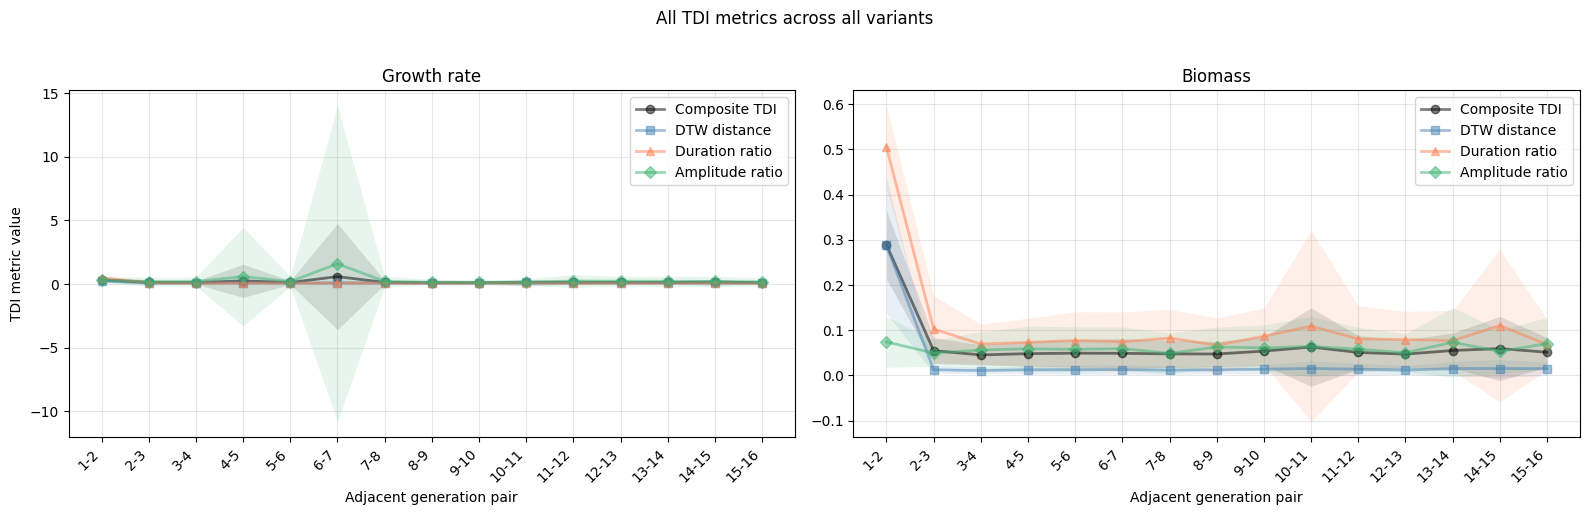

        feature generation_pair  composite_tdi_mean  composite_tdi_std  \
0       Biomass             1-2            0.288891           0.076089   
7       Biomass             2-3            0.054914           0.028673   
8       Biomass             3-4            0.045421           0.022466   
9       Biomass             4-5            0.048217           0.027146   
10      Biomass             5-6            0.049229           0.030508   
11      Biomass             6-7            0.048949           0.032239   
12      Biomass             7-8            0.047739           0.029988   
13      Biomass             8-9            0.047457           0.027722   
14      Biomass            9-10            0.053828           0.031110   
1       Biomass           10-11            0.062828           0.086803   
2       Biomass           11-12            0.050845           0.037078   
3       Biomass           12-13            0.047189           0.031104   
4       Biomass           13-14       

In [20]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the compute_tdi function from tdi_plot.py (use reload to use the latest version)
import importlib
import tdi_plot
importlib.reload(tdi_plot)
compute_tdi = tdi_plot.compute_tdi

# Set project name and seed list
project = "gene_ko_40trial_seed100_succinate"
seed_list = [100, 101]

# Check if df_t is available
if 'df_t' not in globals():
    raise ValueError('df_t is not available. Load the time-series parquet into df_t first.')

# Validate and copy the required columns are present in df_t
ts = df_t.copy()
required_cols = {'variant', 'generation', 'time'}
missing = required_cols.difference(ts.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
feature_map = {
    'Growth rate': 'listeners__mass__instantaneous_growth_rate',
    'Biomass': 'listeners__mass__dry_mass',
}
feature_map = {label: col for label, col in feature_map.items() if col in ts.columns}
if not feature_map:
    raise ValueError('No supported TDI feature columns were found in df_t.')

# Compute TDI metrics for each variant and adjacent generation pairs
records = []
generation_pairs = sorted(ts['generation'].dropna().unique())
for seed in seed_list:
    for variant, variant_df in ts.groupby('variant'):
        variant_df = variant_df.sort_values(['generation', 'time', 'lineage_seed'])
        variant_df = variant_df[variant_df['lineage_seed'] == seed]
        for gen_prev, gen_curr in zip(generation_pairs[:-1], generation_pairs[1:]):
            prev_df = variant_df[variant_df['generation'] == gen_prev]
            curr_df = variant_df[variant_df['generation'] == gen_curr]
            if prev_df.empty or curr_df.empty:
                continue
            for feature_label, feature_col in feature_map.items():
                metrics = compute_tdi(prev_df, curr_df, feature_col)
                records.append(
                    {
                        'variant': variant,
                        'feature': feature_label,
                        'generation_pair': f'{gen_prev}-{gen_curr}',
                        'seed': seed,
                        **metrics,
                    }
                )

results = pd.DataFrame(records)
if results.empty:
    raise ValueError('No TDI records were computed. Check that df_t contains multiple generations for each variant.')

metric_order = ['composite_tdi', 'dtw_distance', 'duration_ratio', 'amplitude_ratio']
metric_labels = {
    'composite_tdi': 'Composite TDI',
    'dtw_distance': 'DTW distance',
    'duration_ratio': 'Duration ratio',
    'amplitude_ratio': 'Amplitude ratio',
}
metric_colors = {
    'composite_tdi': 'black',
    'dtw_distance': 'steelblue',
    'duration_ratio': 'coral',
    'amplitude_ratio': 'mediumseagreen',
}
metric_markers = {
    'composite_tdi': 'o',
    'dtw_distance': 's',
    'duration_ratio': '^',
    'amplitude_ratio': 'D',
}
metric_fill_alpha = 0.12

summary = (
    results.groupby(['feature', 'generation_pair'], as_index=False)
    .agg(
        composite_tdi_mean=('composite_tdi', 'mean'),
        composite_tdi_std=('composite_tdi', 'std'),
        dtw_distance_mean=('dtw_distance', 'mean'),
        dtw_distance_std=('dtw_distance', 'std'),
        duration_ratio_mean=('duration_ratio', 'mean'),
        duration_ratio_std=('duration_ratio', 'std'),
        amplitude_ratio_mean=('amplitude_ratio', 'mean'),
        amplitude_ratio_std=('amplitude_ratio', 'std'),
        count=('composite_tdi', 'count'),
    )
)
summary = summary.fillna(0.0)
summary['generation_start'] = summary['generation_pair'].str.split('-').str[0].astype(int)
summary = summary.sort_values(['feature', 'generation_start'])

save_dir = "/user/home/il22158/work/vEcoli/reading/results/tdi"
os.makedirs(save_dir, exist_ok=True)

combined_name = "tdi_all_variants_growth_rate_biomass_4metrics_mean_std.png"

fig, axes = plt.subplots(1, len(feature_map), figsize=(16, 5), sharey=False)
if len(feature_map) == 1:
    axes = [axes]

for ax, (feature_label, _) in zip(axes, feature_map.items()):
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()

    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(feature_label)
    ax.set_xlabel('Adjacent generation pair')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('TDI metric value')
fig.suptitle('All TDI metrics across all variants', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, combined_name), dpi=300, bbox_inches='tight')
plt.show()

for feature_label in feature_map:
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()
    feature_slug = feature_label.lower().replace(' ', '_')

    fig_feature, ax_feature = plt.subplots(figsize=(9, 4.8))
    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax_feature.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax_feature.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax_feature.set_xticks(x)
    ax_feature.set_xticklabels(labels, rotation=45, ha='right')
    ax_feature.set_title(f'{project} - All TDI metrics across all variants')
    ax_feature.set_xlabel('Adjacent generation pair')
    ax_feature.set_ylabel('TDI metric value')
    ax_feature.grid(True, alpha=0.3)
    ax_feature.legend(loc='best')
    fig_feature.tight_layout()
    fig_feature.savefig(
        os.path.join(save_dir, f'tdi_all_variants_{project}_{feature_slug}_4metrics_mean_std.png'),
        bbox_inches='tight',
    )
    plt.close(fig_feature)

print(summary)
summary.to_csv(os.path.join(save_dir, f'tdi_all_variants_{project}_4metrics_mean_std.csv'), index=False)

### 40 trial KO - no oxygym

#### Individual plot

In [21]:
# Load the saved time-series and read the biomass/growth rate
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_ko_40trial_no_ox_all.parquet"
import pandas as pd
df_t = pd.read_parquet(path)
print('shape', df_t.shape)
print('columns', list(df_t.columns))
print('dtypes')
print(df_t.dtypes.to_string())
print('head')
print(df_t.head(5).to_string())

shape (64647, 8)
columns ['project', 'variant', 'label', 'lineage_seed', 'generation', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
dtypes
project                                        object
variant                                         int64
label                                          object
lineage_seed                                    int64
generation                                      int64
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
head
                         project  variant        label  lineage_seed  generation   time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
0  gene_ko_40trial_seed100_no_ox        1  KO: EG10003           100           1    0.0                                    0.000000                 103.866296
1  gene_ko_40trial_seed100_no_ox        1  KO: EG10003           100

In [8]:
print(df_t.tail(5).to_string())

                             project  variant        label  lineage_seed  generation     time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
64642  gene_ko_40trial_seed100_no_ox       40  KO: EG10054           101          16  57354.0                                    0.000251                 646.359601
64643  gene_ko_40trial_seed100_no_ox       40  KO: EG10054           101          16  57414.0                                    0.000246                 655.923734
64644  gene_ko_40trial_seed100_no_ox       40  KO: EG10054           101          16  57474.0                                    0.000241                 665.170075
64645  gene_ko_40trial_seed100_no_ox       40  KO: EG10054           101          16  57534.0                                    0.000240                 674.721690
64646  gene_ko_40trial_seed100_no_ox       40  KO: EG10054           101          16  57594.0                                    0.000250                 684.763084


Sample command:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox \
    --project-folder gene_ko_40trial_seed100_no_ox \
    --variants 1 \
    --generations 1:16
```

Sample command for altered seed:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox \
    --project-folder gene_ko_40trial_seed100_no_ox \
    --seed 101 \
    --variants 20 \
    --generations 1:16
```

In [9]:
"""Customise command for each variant and generation range"""

variant_col = 'variant'
generation_col = 'generation'

if variant_col not in df_t.columns or generation_col not in df_t.columns:
    raise ValueError('The loaded CSV must contain variant and generation columns.')

for variant, variant_df in df_t.groupby(variant_col):
    max_generation = int(variant_df[generation_col].max())
    if variant_df[generation_col].nunique() <= 1:
        continue

    command = f"""python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox \
    --project-folder gene_ko_40trial_seed100_no_ox \
    --variants {variant} \
    --generations 1:{max_generation}"""

    print(command)

python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox     --project-folder gene_ko_40trial_seed100_no_ox     --variants 1     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox     --project-folder gene_ko_40trial_seed100_no_ox     --variants 2     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox     --project-folder gene_ko_40trial_seed100_no_ox     --variants 3     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_no_ox     --project-folder gene_ko_40trial_seed100_no_ox     --variants 4     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /us

#### Aggregated Plot

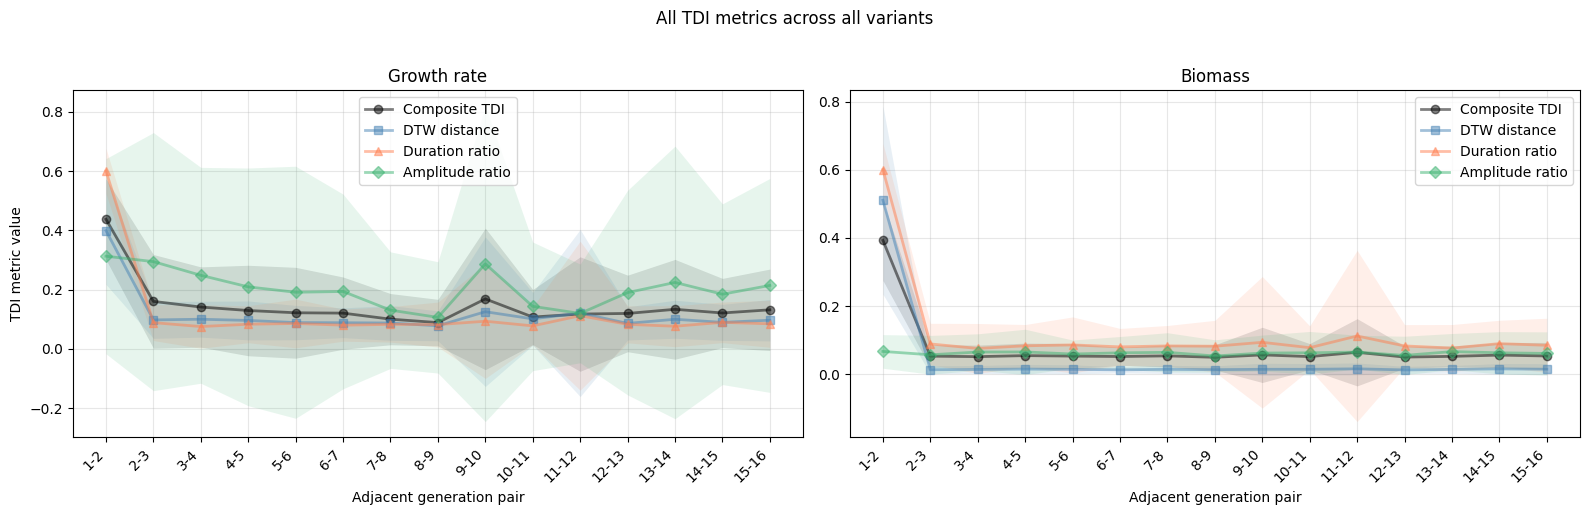

        feature generation_pair  composite_tdi_mean  composite_tdi_std  \
0       Biomass             1-2            0.392823           0.117756   
7       Biomass             2-3            0.053045           0.033568   
8       Biomass             3-4            0.051602           0.033942   
9       Biomass             4-5            0.054654           0.036638   
10      Biomass             5-6            0.053182           0.036995   
11      Biomass             6-7            0.052029           0.026674   
12      Biomass             7-8            0.053870           0.032676   
13      Biomass             8-9            0.049701           0.036806   
14      Biomass            9-10            0.056777           0.081103   
1       Biomass           10-11            0.051724           0.038181   
2       Biomass           11-12            0.064367           0.098690   
3       Biomass           12-13            0.050335           0.032537   
4       Biomass           13-14       

In [22]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the compute_tdi function from tdi_plot.py (use reload to use the latest version)
import importlib
import tdi_plot
importlib.reload(tdi_plot)
compute_tdi = tdi_plot.compute_tdi

# Set project name and seed list
project = "gene_ko_40trial_seed100_no_ox"
seed_list = [100, 101]

# Check if df_t is available
if 'df_t' not in globals():
    raise ValueError('df_t is not available. Load the time-series parquet into df_t first.')

# Validate and copy the required columns are present in df_t
ts = df_t.copy()
required_cols = {'variant', 'generation', 'time'}
missing = required_cols.difference(ts.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
feature_map = {
    'Growth rate': 'listeners__mass__instantaneous_growth_rate',
    'Biomass': 'listeners__mass__dry_mass',
}
feature_map = {label: col for label, col in feature_map.items() if col in ts.columns}
if not feature_map:
    raise ValueError('No supported TDI feature columns were found in df_t.')

# Compute TDI metrics for each variant and adjacent generation pairs
records = []
generation_pairs = sorted(ts['generation'].dropna().unique())
for seed in seed_list:
    for variant, variant_df in ts.groupby('variant'):
        variant_df = variant_df.sort_values(['generation', 'time', 'lineage_seed'])
        variant_df = variant_df[variant_df['lineage_seed'] == seed]
        for gen_prev, gen_curr in zip(generation_pairs[:-1], generation_pairs[1:]):
            prev_df = variant_df[variant_df['generation'] == gen_prev]
            curr_df = variant_df[variant_df['generation'] == gen_curr]
            if prev_df.empty or curr_df.empty:
                continue
            for feature_label, feature_col in feature_map.items():
                metrics = compute_tdi(prev_df, curr_df, feature_col)
                records.append(
                    {
                        'variant': variant,
                        'feature': feature_label,
                        'generation_pair': f'{gen_prev}-{gen_curr}',
                        'seed': seed,
                        **metrics,
                    }
                )

results = pd.DataFrame(records)
if results.empty:
    raise ValueError('No TDI records were computed. Check that df_t contains multiple generations for each variant.')

metric_order = ['composite_tdi', 'dtw_distance', 'duration_ratio', 'amplitude_ratio']
metric_labels = {
    'composite_tdi': 'Composite TDI',
    'dtw_distance': 'DTW distance',
    'duration_ratio': 'Duration ratio',
    'amplitude_ratio': 'Amplitude ratio',
}
metric_colors = {
    'composite_tdi': 'black',
    'dtw_distance': 'steelblue',
    'duration_ratio': 'coral',
    'amplitude_ratio': 'mediumseagreen',
}
metric_markers = {
    'composite_tdi': 'o',
    'dtw_distance': 's',
    'duration_ratio': '^',
    'amplitude_ratio': 'D',
}
metric_fill_alpha = 0.12

summary = (
    results.groupby(['feature', 'generation_pair'], as_index=False)
    .agg(
        composite_tdi_mean=('composite_tdi', 'mean'),
        composite_tdi_std=('composite_tdi', 'std'),
        dtw_distance_mean=('dtw_distance', 'mean'),
        dtw_distance_std=('dtw_distance', 'std'),
        duration_ratio_mean=('duration_ratio', 'mean'),
        duration_ratio_std=('duration_ratio', 'std'),
        amplitude_ratio_mean=('amplitude_ratio', 'mean'),
        amplitude_ratio_std=('amplitude_ratio', 'std'),
        count=('composite_tdi', 'count'),
    )
)
summary = summary.fillna(0.0)
summary['generation_start'] = summary['generation_pair'].str.split('-').str[0].astype(int)
summary = summary.sort_values(['feature', 'generation_start'])

save_dir = "/user/home/il22158/work/vEcoli/reading/results/tdi"
os.makedirs(save_dir, exist_ok=True)

combined_name = "tdi_all_variants_growth_rate_biomass_4metrics_mean_std.png"

fig, axes = plt.subplots(1, len(feature_map), figsize=(16, 5), sharey=False)
if len(feature_map) == 1:
    axes = [axes]

for ax, (feature_label, _) in zip(axes, feature_map.items()):
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()

    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(feature_label)
    ax.set_xlabel('Adjacent generation pair')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('TDI metric value')
fig.suptitle('All TDI metrics across all variants', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, combined_name), dpi=300, bbox_inches='tight')
plt.show()

for feature_label in feature_map:
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()
    feature_slug = feature_label.lower().replace(' ', '_')

    fig_feature, ax_feature = plt.subplots(figsize=(9, 4.8))
    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax_feature.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax_feature.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax_feature.set_xticks(x)
    ax_feature.set_xticklabels(labels, rotation=45, ha='right')
    ax_feature.set_title(f'{project} - All TDI metrics across all variants')
    ax_feature.set_xlabel('Adjacent generation pair')
    ax_feature.set_ylabel('TDI metric value')
    ax_feature.grid(True, alpha=0.3)
    ax_feature.legend(loc='best')
    fig_feature.tight_layout()
    fig_feature.savefig(
        os.path.join(save_dir, f'tdi_all_variants_{project}_{feature_slug}_4metrics_mean_std.png'),
        bbox_inches='tight',
    )
    plt.close(fig_feature)

print(summary)
summary.to_csv(os.path.join(save_dir, f'tdi_all_variants_{project}_4metrics_mean_std.csv'), index=False)

### 40 trial KO - acetate

#### Individual plot

In [1]:
# Load the saved time-series and read the biomass/growth rate
path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_ko_40trial_acetate_all.parquet"
import pandas as pd
df_t = pd.read_parquet(path)
print('shape', df_t.shape)
print('columns', list(df_t.columns))
print('dtypes')
print(df_t.dtypes.to_string())
print('head')
print(df_t.head(5).to_string())

shape (66329, 8)
columns ['project', 'variant', 'label', 'lineage_seed', 'generation', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
dtypes
project                                        object
variant                                         int64
label                                          object
lineage_seed                                    int64
generation                                      int64
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
head
                           project  variant        label  lineage_seed  generation   time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
0  gene_ko_40trial_seed100_acetate        1  KO: EG10003           100           1    0.0                                    0.000000                  75.097147
1  gene_ko_40trial_seed100_acetate        1  KO: EG10003        

In [2]:
print(df_t.tail(5).to_string())

                               project  variant        label  lineage_seed  generation     time  listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass
66324  gene_ko_40trial_seed100_acetate       40  KO: EG10054           101          16  57907.0                                    0.000210                 619.723468
66325  gene_ko_40trial_seed100_acetate       40  KO: EG10054           101          16  57967.0                                    0.000212                 627.448358
66326  gene_ko_40trial_seed100_acetate       40  KO: EG10054           101          16  58027.0                                    0.000215                 635.459458
66327  gene_ko_40trial_seed100_acetate       40  KO: EG10054           101          16  58087.0                                    0.000217                 643.767116
66328  gene_ko_40trial_seed100_acetate       40  KO: EG10054           101          16  58147.0                                    0.000214                 652.04390

Sample command:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate \
    --project-folder gene_ko_40trial_seed100_acetate \
    --variants 1 \
    --generations 1:16
```

Sample command for altered seed:

```bash
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate \
    --project-folder gene_ko_40trial_seed100_acetate \
    --seed 101 \
    --variants 1 \
    --generations 1:16
```

In [3]:
"""Customise command for each variant and generation range"""

variant_col = 'variant'
generation_col = 'generation'

if variant_col not in df_t.columns or generation_col not in df_t.columns:
    raise ValueError('The loaded CSV must contain variant and generation columns.')

for variant, variant_df in df_t.groupby(variant_col):
    max_generation = int(variant_df[generation_col].max())
    if variant_df[generation_col].nunique() <= 1:
        continue

    command = f"""python /user/home/il22158/work/vEcoli/reading/tdi_plot.py \
    --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate \
    --project-folder gene_ko_40trial_seed100_acetate \
    --variants {variant} \
    --generations 1:{max_generation}"""

    print(command)

python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate     --project-folder gene_ko_40trial_seed100_acetate     --variants 1     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate     --project-folder gene_ko_40trial_seed100_acetate     --variants 2     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate     --project-folder gene_ko_40trial_seed100_acetate     --variants 3     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py     --save-dir /user/home/il22158/work/vEcoli/reading/results/tdi/40trialKO_acetate     --project-folder gene_ko_40trial_seed100_acetate     --variants 4     --generations 1:16
python /user/home/il22158/work/vEcoli/reading/tdi_plot.py   

#### Aggregated Plot

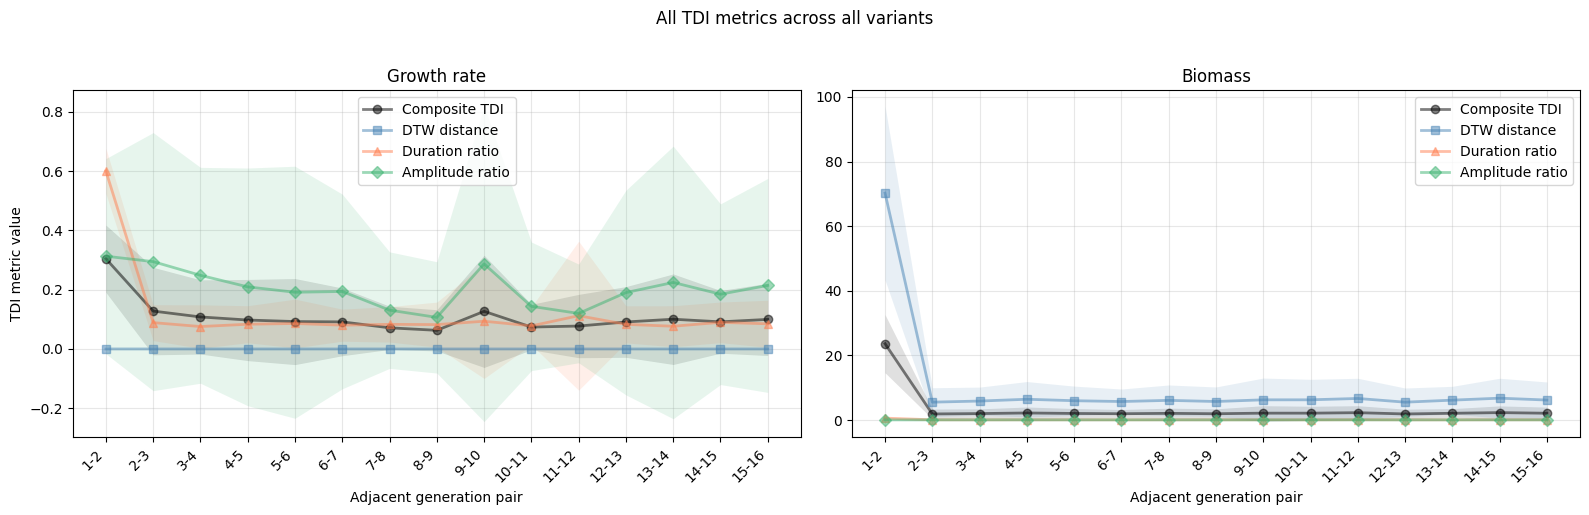

        feature generation_pair  composite_tdi_mean  composite_tdi_std  \
0       Biomass             1-2           23.642061           8.993462   
7       Biomass             2-3            1.896975           1.515539   
8       Biomass             3-4            2.009822           1.466131   
9       Biomass             4-5            2.197522           1.854781   
10      Biomass             5-6            2.045906           1.536723   
11      Biomass             6-7            1.960932           1.311196   
12      Biomass             7-8            2.083554           1.610629   
13      Biomass             8-9            1.960374           1.531287   
14      Biomass            9-10            2.141032           2.313132   
1       Biomass           10-11            2.137342           2.143596   
2       Biomass           11-12            2.288836           2.162927   
3       Biomass           12-13            1.893303           1.485093   
4       Biomass           13-14       

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the compute_tdi function from tdi_plot.py
from tdi_plot import compute_tdi

# Set project name and seed list
project = "gene_ko_40trial_seed100_acetate"
seed_list = [100, 101]

# Check if df_t is available
if 'df_t' not in globals():
    raise ValueError('df_t is not available. Load the time-series parquet into df_t first.')

# Validate and copy the required columns are present in df_t
ts = df_t.copy()
required_cols = {'variant', 'generation', 'time'}
missing = required_cols.difference(ts.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
feature_map = {
    'Growth rate': 'listeners__mass__instantaneous_growth_rate',
    'Biomass': 'listeners__mass__dry_mass',
}
feature_map = {label: col for label, col in feature_map.items() if col in ts.columns}
if not feature_map:
    raise ValueError('No supported TDI feature columns were found in df_t.')

# Compute TDI metrics for each variant and adjacent generation pairs
records = []
generation_pairs = sorted(ts['generation'].dropna().unique())
for seed in seed_list:
    for variant, variant_df in ts.groupby('variant'):
        variant_df = variant_df.sort_values(['generation', 'time', 'lineage_seed'])
        variant_df = variant_df[variant_df['lineage_seed'] == seed]
        for gen_prev, gen_curr in zip(generation_pairs[:-1], generation_pairs[1:]):
            prev_df = variant_df[variant_df['generation'] == gen_prev]
            curr_df = variant_df[variant_df['generation'] == gen_curr]
            if prev_df.empty or curr_df.empty:
                continue
            for feature_label, feature_col in feature_map.items():
                metrics = compute_tdi(prev_df, curr_df, feature_col)
                records.append(
                    {
                        'variant': variant,
                        'feature': feature_label,
                        'generation_pair': f'{gen_prev}-{gen_curr}',
                        'seed': seed,
                        **metrics,
                    }
                )

results = pd.DataFrame(records)
if results.empty:
    raise ValueError('No TDI records were computed. Check that df_t contains multiple generations for each variant.')

metric_order = ['composite_tdi', 'dtw_distance', 'duration_ratio', 'amplitude_ratio']
metric_labels = {
    'composite_tdi': 'Composite TDI',
    'dtw_distance': 'DTW distance',
    'duration_ratio': 'Duration ratio',
    'amplitude_ratio': 'Amplitude ratio',
}
metric_colors = {
    'composite_tdi': 'black',
    'dtw_distance': 'steelblue',
    'duration_ratio': 'coral',
    'amplitude_ratio': 'mediumseagreen',
}
metric_markers = {
    'composite_tdi': 'o',
    'dtw_distance': 's',
    'duration_ratio': '^',
    'amplitude_ratio': 'D',
}
metric_fill_alpha = 0.12

summary = (
    results.groupby(['feature', 'generation_pair'], as_index=False)
    .agg(
        composite_tdi_mean=('composite_tdi', 'mean'),
        composite_tdi_std=('composite_tdi', 'std'),
        dtw_distance_mean=('dtw_distance', 'mean'),
        dtw_distance_std=('dtw_distance', 'std'),
        duration_ratio_mean=('duration_ratio', 'mean'),
        duration_ratio_std=('duration_ratio', 'std'),
        amplitude_ratio_mean=('amplitude_ratio', 'mean'),
        amplitude_ratio_std=('amplitude_ratio', 'std'),
        count=('composite_tdi', 'count'),
    )
)
summary = summary.fillna(0.0)
summary['generation_start'] = summary['generation_pair'].str.split('-').str[0].astype(int)
summary = summary.sort_values(['feature', 'generation_start'])

save_dir = "/user/home/il22158/work/vEcoli/reading/results/tdi"
os.makedirs(save_dir, exist_ok=True)

combined_name = "tdi_all_variants_growth_rate_biomass_4metrics_mean_std.png"

fig, axes = plt.subplots(1, len(feature_map), figsize=(16, 5), sharey=False)
if len(feature_map) == 1:
    axes = [axes]

for ax, (feature_label, _) in zip(axes, feature_map.items()):
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()

    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(feature_label)
    ax.set_xlabel('Adjacent generation pair')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('TDI metric value')
fig.suptitle('All TDI metrics across all variants', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, combined_name), dpi=300, bbox_inches='tight')
plt.show()

for feature_label in feature_map:
    feature_summary = summary[summary['feature'] == feature_label].reset_index(drop=True)
    x = np.arange(len(feature_summary))
    labels = feature_summary['generation_pair'].to_list()
    feature_slug = feature_label.lower().replace(' ', '_')

    fig_feature, ax_feature = plt.subplots(figsize=(9, 4.8))
    for metric in metric_order:
        y = feature_summary[f'{metric}_mean'].to_numpy()
        y_std = feature_summary[f'{metric}_std'].to_numpy()
        color = metric_colors[metric]
        marker = metric_markers[metric]
        ax_feature.plot(
            x,
            y,
            marker=marker,
            linewidth=2,
            label=metric_labels[metric],
            alpha=0.5,
            color=color,
            zorder=3,
        )
        ax_feature.fill_between(
            x,
            y - y_std,
            y + y_std,
            facecolor=color,
            edgecolor=color,
            alpha=metric_fill_alpha,
            linewidth=0,
            zorder=2,
        )

    ax_feature.set_xticks(x)
    ax_feature.set_xticklabels(labels, rotation=45, ha='right')
    ax_feature.set_title(f'{project} - All TDI metrics across all variants')
    ax_feature.set_xlabel('Adjacent generation pair')
    ax_feature.set_ylabel('TDI metric value')
    ax_feature.grid(True, alpha=0.3)
    ax_feature.legend(loc='best')
    fig_feature.tight_layout()
    fig_feature.savefig(
        os.path.join(save_dir, f'tdi_all_variants_{project}_{feature_slug}_4metrics_mean_std.png'),
        bbox_inches='tight',
    )
    plt.close(fig_feature)

print(summary)
summary.to_csv(os.path.join(save_dir, f'tdi_all_variants_{project}_4metrics_mean_std.csv'), index=False)

# Results and Conclusion

## Data sources
- AA CSV: [tdi_all_variants_gene_ko_40trial_seed100_aa_4metrics_mean_std.csv](/user/home/il22158/work/vEcoli/reading/results/tdi/tdi_all_variants_gene_ko_40trial_seed100_aa_4metrics_mean_std.csv)
- Basal CSV: [tdi_all_variants_gene_ko_40trial_seed100_basal_4metrics_mean_std.csv](/user/home/il22158/work/vEcoli/reading/results/tdi/tdi_all_variants_gene_ko_40trial_seed100_basal_4metrics_mean_std.csv)
- No ox CSV: [tdi_all_variants_gene_ko_40trial_seed100_no_ox_4metrics_mean_std.csv](/user/home/il22158/work/vEcoli/reading/results/tdi/tdi_all_variants_gene_ko_40trial_seed100_no_ox_4metrics_mean_std.csv)
- Succinate CSV: [tdi_all_variants_gene_ko_40trial_seed100_succinate_4metrics_mean_std.csv](/user/home/il22158/work/vEcoli/reading/results/tdi/tdi_all_variants_gene_ko_40trial_seed100_succinate_4metrics_mean_std.csv)

## Basal Media
### Biomass change
![Basal biomass TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_basal_biomass_4metrics_mean_std.png)

### Growth rate change
![Basal growth rate TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_basal_growth_rate_4metrics_mean_std.png)

## AA Media 
### Biomass change
![AA biomass TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_aa_biomass_4metrics_mean_std.png)

### Growth rate change
![AA growth rate TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_aa_growth_rate_4metrics_mean_std.png)

## No Oxygym Media
### Biomass change
![No ox biomass TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_no_ox_biomass_4metrics_mean_std.png)

### Growth change
![No ox growth rate TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_no_ox_growth_rate_4metrics_mean_std.png)

## Succinate Media
### Biomass change
![Succinate biomass TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_succinate_biomass_4metrics_mean_std.png)

### Growth  change
![Succinate growth rate TDI](results/tdi/tdi_all_variants_gene_ko_40trial_seed100_succinate_growth_rate_4metrics_mean_std.png)

## Results and Discussion

The TDI framework in `tdi_plot.py` should be interpreted as a relative change metric rather than a raw DTW score. The DTW term is normalized by sequence length and by the mean level of the two adjacent generations, and the composite index is the average of DTW, duration ratio, and amplitude ratio. Lower values therefore indicate stronger similarity between adjacent generations. Across the 40-trial knockout sets, the dominant pattern is an early transient followed by a late regime in which adjacent-generation changes are smaller and more regular. Growth rate generally stabilizes earlier than biomass, whereas biomass may continue to increase in absolute terms even when the normalized TDI is low, because the metric captures relative change rather than absolute accumulation.

| Media | Proposed generation window | Biomass mean composite TDI | Growth-rate mean composite TDI | Interpretation |
| --- | --- | ---: | ---: | --- |
| Basal | 6-10 | 0.049 | 0.097 | Clear late stabilization; both features are at or below the 0.1 level in the selected window. |
| AA | 6-10 | 0.053 | 0.120 | Biomass is stable, but growth rate remains slightly above 0.1 and is less compact than basal. |
| No oxygen | 6-10 | 0.049 | 0.103 | Stable biomass and near-threshold growth-rate convergence in the late regime. |
| Succinate | 8-14 | 0.054 | 0.122 | *Later heterogeneous regime |

These window means show that the biomass series are comfortably below 0.1 in all proposed ranges, whereas the growth-rate series are more conservative: basal is clearly below 0.1, AA and no oxygen are slightly above 0.1, and succinate remains the most variable condition. For that reason, the proposed ranges should be treated as practical stabilization windows rather than strict convergence cutoffs.

For future simulations, 6-10 is a reasonable efficiency-oriented choice for basal, AA, and no oxygen, and 8-14 is a defensible late-window choice for succinate. This balances interpretability with compute and storage cost, while preserving the biologically relevant post-transient regime. The total generations are kept to be eight, corresponding to an early study that traces the cell fate (Gherman et al., 2025).
